# AIT Log Data Set V2.0 - fox

In [292]:
import pandas as pd
import hashlib
import numpy as np
import matplotlib.pyplot as plt

## Concatenate Sensor Files

In [293]:
dataset = "aitv2"
scenario = "fox"
data_dir = f"../data/interim/{dataset}/{scenario}/flows_labeled"
sensor_hosts = ["cloud_share", "inet_firewall", "internal_share", "intranet_server", "mail", "vpn", "webserver"]

In [294]:
# all_sensor_files = []
# for sensor_host in sensor_hosts:
#     df = pd.read_csv(
#         f"{data_dir}/{sensor_host}_labeled.csv"
#     )
#     df["sensor_host"] = sensor_host
#     all_sensor_files.append(df)

# df_all_sensors = pd.concat(all_sensor_files, ignore_index=True)
# df_all_sensors = df_all_sensors.sort_values("start_time").reset_index(drop=True)

# df_all_sensors.head()

In [295]:
df_all_sensors = pd.read_csv(f"{data_dir}/all_labeled.csv")

## Trim to Simulation Period

In [296]:
# Convert start_time and end_time from seconds to datetime
df_all_sensors["start_time_dt"] = pd.to_datetime(df_all_sensors["start_time"], unit="s")
df_all_sensors["end_time_dt"] = pd.to_datetime(df_all_sensors["end_time"], unit="s")

print(f"Full dataset time range: {df_all_sensors['start_time_dt'].min()} to {df_all_sensors['end_time_dt'].max()}")
print("Total flows in combined dataset:", len(df_all_sensors))

Full dataset time range: 2022-01-14 11:20:16.140374899 to 2022-01-20 06:47:24.788824081
Total flows in combined dataset: 554458


In [297]:
# Trim to simulation period
sim_start = pd.Timestamp("2022-01-15 00:00")
sim_end   = pd.Timestamp("2022-01-20 00:00")

df_sim = df_all_sensors[(df_all_sensors["start_time_dt"] >= sim_start) & (df_all_sensors["end_time_dt"] <= sim_end)]

print(f"Simulation period: {sim_start} to {sim_end}")
print(f"Total flows in simulation period: {len(df_sim)}")

Simulation period: 2022-01-15 00:00:00 to 2022-01-20 00:00:00
Total flows in simulation period: 497617


## Sanity Check Labeling

### Load Netflow Data

In [298]:
netflows_path = f"../data/interim/{dataset}/{scenario}/labels/all_netflows.csv"

df_netflows = pd.read_csv(netflows_path)
df_netflows_labels_counts = df_netflows["label"].value_counts()
netflows_labels = df_netflows["label"].unique()

print(netflows_labels)
print(df_netflows_labels_counts)
print()

['browsing/update' 'service_scan' 'online_cracking' 'benign_share' 'proxy'
 'host_discover_dmz' 'SSH' 'mail' 'HTTPS' 'DNS'
 'update/command on unassigned port' 'monitoring' 'HTTP(S) intra' 'HTTP'
 'host_discover_local' 'wpscan' 'dirb_scan' 'upload_rce_shell'
 'check_user_id' 'check_netstat_t' 'read_resolv' 'check_network_config'
 'check_ps_a' 'check_release' 'read_group' 'read_passwd' 'check_date'
 'list_web_dir' 'check_wp_config' 'dump_wp_users' 'read_profile'
 'dns_brute_force_start' 'HTTP(S) DMZ' 'broken flow - benign'
 'data exfiltration' 'mDNSv6' 'mDNS' 'bootp' 'NTP'
 'systemd-resolver (local)' 'benign DNS - attacker requesting updates'
 'benign DNS' 'OpenVPN' 'QUIC' 'STUN VoIP' 'NetBIOS']
label
benign DNS                                  79043
proxy                                       64434
HTTPS                                       34918
host_discover_local                         32788
browsing/update                             27876
benign_share                            

In [299]:
# netflows_dir = f"../data/raw/{dataset}/{scenario}/netflows"
# files = ["tcp_complete.csv", "tcp_nocomplete.csv", "udp_complete.csv"]

# for file in files:
#     netflows_path = f"{netflows_dir}/{file}"
#     df_netflows = pd.read_csv(netflows_path)
#     df_netflows_labels_counts = df_netflows["label"].value_counts()
#     netflows_labels = df_netflows["label"].unique()

#     print(f"Netflows file: {file}")
#     print(netflows_labels)
#     print(df_netflows_labels_counts)
#     print()

### Check Labeling

In [300]:
def get_observed_labels_and_counts(df):
    observed_labels = set()
    observed_labels_counts = {}
    for label in df["label"].unique():
        observed_labels.add(label)
        observed_labels_counts[label] = len(df[df["label"] == label])
    return observed_labels, observed_labels_counts

observed_labels, observed_labels_counts = get_observed_labels_and_counts(df_sim)

In [301]:
print("Unique labels observed across all sensors:")
print(list(observed_labels))

print("Labels in netflows but not observed:")
missing_labels = [label for label in netflows_labels if label not in observed_labels]
print(missing_labels)

Unique labels observed across all sensors:
['NTP', 'HTTPS', 'upload_rce_shell', 'service_scan', 'update/command on unassigned port', 'SSH', 'bootp', 'dns_brute_force_start', 'browsing/update', 'online_cracking', 'read_profile', 'host_discover_dmz', 'read_group', 'read_passwd', 'dump_wp_users', 'DNS', 'monitoring', 'HTTP', 'proxy', 'mail', 'check_netstat_t', 'check_release', 'host_discover_local', 'dirb_scan', 'benign', 'list_web_dir', 'HTTP(S) intra', 'HTTP(S) DMZ', 'wpscan', 'check_ps_a', 'broken flow - benign', 'benign DNS', 'check_date', 'QUIC', 'STUN VoIP', 'read_resolv', 'check_wp_config', 'check_user_id', 'check_network_config', 'benign_share', 'OpenVPN']
Labels in netflows but not observed:
['data exfiltration', 'mDNSv6', 'mDNS', 'systemd-resolver (local)', 'benign DNS - attacker requesting updates', 'NetBIOS']


In [302]:
indicators = []

missing_labels = ["data exfiltration"]
for missing_label in missing_labels:
    # print(f"Flows with label '{missing_label}' in netflows:")
    # print(df_netflows[df_netflows["label"] == missing_label])
    df_mis = df_netflows[df_netflows["label"] == missing_label]
    indicators.append(df_mis[["src_ip", "dst_ip", "sport", "dport"]].drop_duplicates())

print("Indicators for missing labels:")
for label, indicator in zip(missing_labels, indicators):
    print(f"Label: {label}")
    print(indicator)
    print()

Indicators for missing labels:
Label: data exfiltration
                 src_ip          dst_ip  sport  dport
232817  192.168.255.254  192.168.130.77   4807     53
232818  192.168.255.254  192.168.130.77  32673     53
232819  192.168.255.254  192.168.130.77  25455     53
232820  192.168.255.254  192.168.130.77  54197     53
232821  192.168.255.254  192.168.130.77  50458     53
...                 ...             ...    ...    ...
249084  192.168.255.254  192.168.130.77  40059     53
249085  192.168.255.254  192.168.130.77  13976     53
249086  192.168.255.254  192.168.130.77  58006     53
249087  192.168.255.254  192.168.130.77   5204     53
249088  192.168.255.254  192.168.130.77  11429     53

[13109 rows x 4 columns]



In [303]:
for label in observed_labels:
    print(f"Observed number of flows with label '{label}': {observed_labels_counts[label]}")
    print(f"Number of flows with label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with label 'NTP': 7316
Number of flows with label 'NTP' in netflows: 10084

Observed number of flows with label 'HTTPS': 69556
Number of flows with label 'HTTPS' in netflows: 34918

Observed number of flows with label 'upload_rce_shell': 4
Number of flows with label 'upload_rce_shell' in netflows: 2

Observed number of flows with label 'service_scan': 20165
Number of flows with label 'service_scan' in netflows: 13901

Observed number of flows with label 'update/command on unassigned port': 2
Number of flows with label 'update/command on unassigned port' in netflows: 2

Observed number of flows with label 'SSH': 35
Number of flows with label 'SSH' in netflows: 19

Observed number of flows with label 'bootp': 171
Number of flows with label 'bootp' in netflows: 1334

Observed number of flows with label 'dns_brute_force_start': 1192
Number of flows with label 'dns_brute_force_start' in netflows: 1192

Observed number of flows with label 'browsing/update': 25154
Num

### Remove Duplicates

In [304]:
def compute_hash(df: pd.DataFrame, columns: list) -> pd.Series:
    return (
        df[columns]
        .astype(str)
        .agg("|".join, axis=1)
        .apply(lambda x: hashlib.md5(x.encode()).hexdigest())
    )

In [305]:
df_sim["start_time_match"] = df_sim["start_time"].round(1)
df_sim["end_time_match"] = df_sim["end_time"].round(1)

match_columns = [col for col in df_sim.columns if col not in ["flow_id", "start_time", "end_time", "sensor_host"]]
match_columns.append("start_time_match")
match_columns.append("end_time_match")
print("Matching columns:", match_columns)

# Compute flow hash for all sensor flows
df_sim["flow_hash"] = compute_hash(df_sim, match_columns)

Matching columns: ['duration', 'src_ip', 'sport', 'dst_ip', 'dport', 'proto', 'service', 'orig_bytes', 'resp_bytes', 'conn_state', 'local_orig', 'local_resp', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tunnel_parents', 'ip_proto', 'flow_hash', 'label', 'start_time_dt', 'end_time_dt', 'start_time_match', 'end_time_match', 'start_time_match', 'end_time_match']


/tmp/ipykernel_29555/3310084976.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sim["start_time_match"] = df_sim["start_time"].round(1)
/tmp/ipykernel_29555/3310084976.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sim["end_time_match"] = df_sim["end_time"].round(1)
/tmp/ipykernel_29555/3310084976.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

In [306]:
# Remove duplicates by keeping only one entry per flow hash and sensor host
df_sim_no_duplicates = (
    df_sim
    .drop_duplicates(subset=["flow_hash", "sensor_host"])
    .drop(columns=["flow_hash", "start_time_match", "end_time_match"])
)

print("Original dataset shape:", df_sim.shape)
print("Final dataset shape:", df_sim_no_duplicates.shape)

Original dataset shape: (497617, 30)
Final dataset shape: (358477, 27)


In [307]:
observed_labels_no_duplicates, observed_labels_counts_no_duplicates = \
    get_observed_labels_and_counts(df_sim_no_duplicates)

for label in observed_labels_no_duplicates:
    print(f"Observed number of flows with label '{label}': {observed_labels_counts_no_duplicates[label]}")
    print(f"Number of flows with label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with label 'NTP': 7316
Number of flows with label 'NTP' in netflows: 10084

Observed number of flows with label 'HTTPS': 34894
Number of flows with label 'HTTPS' in netflows: 34918

Observed number of flows with label 'upload_rce_shell': 2
Number of flows with label 'upload_rce_shell' in netflows: 2

Observed number of flows with label 'service_scan': 11039
Number of flows with label 'service_scan' in netflows: 13901

Observed number of flows with label 'update/command on unassigned port': 2
Number of flows with label 'update/command on unassigned port' in netflows: 2

Observed number of flows with label 'SSH': 19
Number of flows with label 'SSH' in netflows: 19

Observed number of flows with label 'bootp': 171
Number of flows with label 'bootp' in netflows: 1334

Observed number of flows with label 'dns_brute_force_start': 1192
Number of flows with label 'dns_brute_force_start' in netflows: 1192

Observed number of flows with label 'browsing/update': 25154
Num

### Save Final Dataset

In [308]:
df_sim_no_duplicates.to_csv(f"{data_dir}/all_labeled_sim.csv", index=False)
print("Combined dataset shape:", df_sim_no_duplicates.shape)
df_sim_no_duplicates.head()

Combined dataset shape: (358477, 27)


,flow_id,start_time,end_time,duration,src_ip,sport,dst_ip,dport,proto,service,...,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,ip_proto,label,sensor_host,start_time_dt,end_time_dt
51341,f1921,1.642205e+09,1.642205e+09,0.099298,10.35.35.206,60538,91.189.91.157,123,udp,ntp,...,1,76,1,76,-,17,benign,intranet_server,2022-01-15 00:00:00.869369984,2022-01-15 00:00:00.968667984
51342,f14196,1.642205e+09,1.642205e+09,0.098276,192.168.128.4,60538,91.189.91.157,123,udp,ntp,...,1,76,1,76,-,17,benign,inet_firewall,2022-01-15 00:00:00.870096922,2022-01-15 00:00:00.968372822
51343,f3334,1.642205e+09,1.642205e+09,0.053324,172.17.129.140,43702,10.35.33.111,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,cloud_share,2022-01-15 00:00:02.130912066,2022-01-15 00:00:02.184236050
51345,f5126,1.642205e+09,1.642205e+09,0.051889,172.17.129.140,43702,10.35.33.111,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,internal_share,2022-01-15 00:00:02.131725073,2022-01-15 00:00:02.183614016
51347,f3335,1.642205e+09,1.642205e+09,0.012432,172.17.129.140,43704,10.35.33.111,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,cloud_share,2022-01-15 00:00:02.226455927,2022-01-15 00:00:02.238888025


## Plotting

In [309]:
df = df_sim_no_duplicates.copy()

### Plotting Functions

In [310]:
import matplotlib.dates as mdates


In [311]:
def plot_event_raster(df_attack, order, attack=False, invert_y=True):

    plt.figure(figsize=(14, 0.35 * len(order)))

    sample = df_attack.sample(
        min(len(df_attack), 5000),
        random_state=0
    ).sort_values("start_time_dt")

    label_to_idx = {lbl: i for i, lbl in enumerate(order)}

    ys = sample['label'].map(label_to_idx).astype(float)

    # jitter to reveal density
    ys += np.random.uniform(-0.15, 0.15, size=len(ys))

    # horizontal guides
    for y in label_to_idx.values():
        plt.axhline(y, color="lightgray", lw=0.5, zorder=0)

    plt.scatter(
        sample['start_time_dt'],  
        ys,
        s=2,
        alpha=0.5,
        rasterized=True
    )

    plt.yticks(list(label_to_idx.values()), list(label_to_idx.keys()))

    plt.grid(axis="x", linestyle=":", alpha=0.4)

    plt.xlabel("Time")
    plt.ylabel("Event Type")
    plt.title("Attack Event Timeline (Sampled Raster)", pad=12)

    ax = plt.gca()

    if attack:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        plt.xticks(rotation=30)

    if invert_y:
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

### Analyze All Events

In [312]:
all_labels = list(netflows_labels)
all_labels.append("benign")
print("All labels (netflows + benign):", all_labels)

All labels (netflows + benign): ['browsing/update', 'service_scan', 'online_cracking', 'benign_share', 'proxy', 'host_discover_dmz', 'SSH', 'mail', 'HTTPS', 'DNS', 'update/command on unassigned port', 'monitoring', 'HTTP(S) intra', 'HTTP', 'host_discover_local', 'wpscan', 'dirb_scan', 'upload_rce_shell', 'check_user_id', 'check_netstat_t', 'read_resolv', 'check_network_config', 'check_ps_a', 'check_release', 'read_group', 'read_passwd', 'check_date', 'list_web_dir', 'check_wp_config', 'dump_wp_users', 'read_profile', 'dns_brute_force_start', 'HTTP(S) DMZ', 'broken flow - benign', 'data exfiltration', 'mDNSv6', 'mDNS', 'bootp', 'NTP', 'systemd-resolver (local)', 'benign DNS - attacker requesting updates', 'benign DNS', 'OpenVPN', 'QUIC', 'STUN VoIP', 'NetBIOS', 'benign']


In [313]:
phase_bounds_sim = (
    df[df['label'].isin(all_labels)]
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_sim

,min,max
label,,
benign,2022-01-15 00:00:00.869369984,2022-01-19 23:59:58.449929953
benign_share,2022-01-15 00:00:02.130912066,2022-01-19 23:45:03.798696995
benign DNS,2022-01-15 00:00:03.113534927,2022-01-19 23:56:57.619887114
NTP,2022-01-15 00:00:24.993254900,2022-01-19 23:59:59.055074930
monitoring,2022-01-15 00:09:12.140852928,2022-01-19 23:39:09.491734982
browsing/update,2022-01-15 00:51:09.932920933,2022-01-19 23:06:25.648124933
broken flow - benign,2022-01-15 01:53:42.224975109,2022-01-19 22:04:08.124752998
bootp,2022-01-15 02:59:23.647079945,2022-01-19 22:53:19.316428900
HTTP(S) intra,2022-01-15 06:20:14.662290096,2022-01-19 20:32:45.343213081


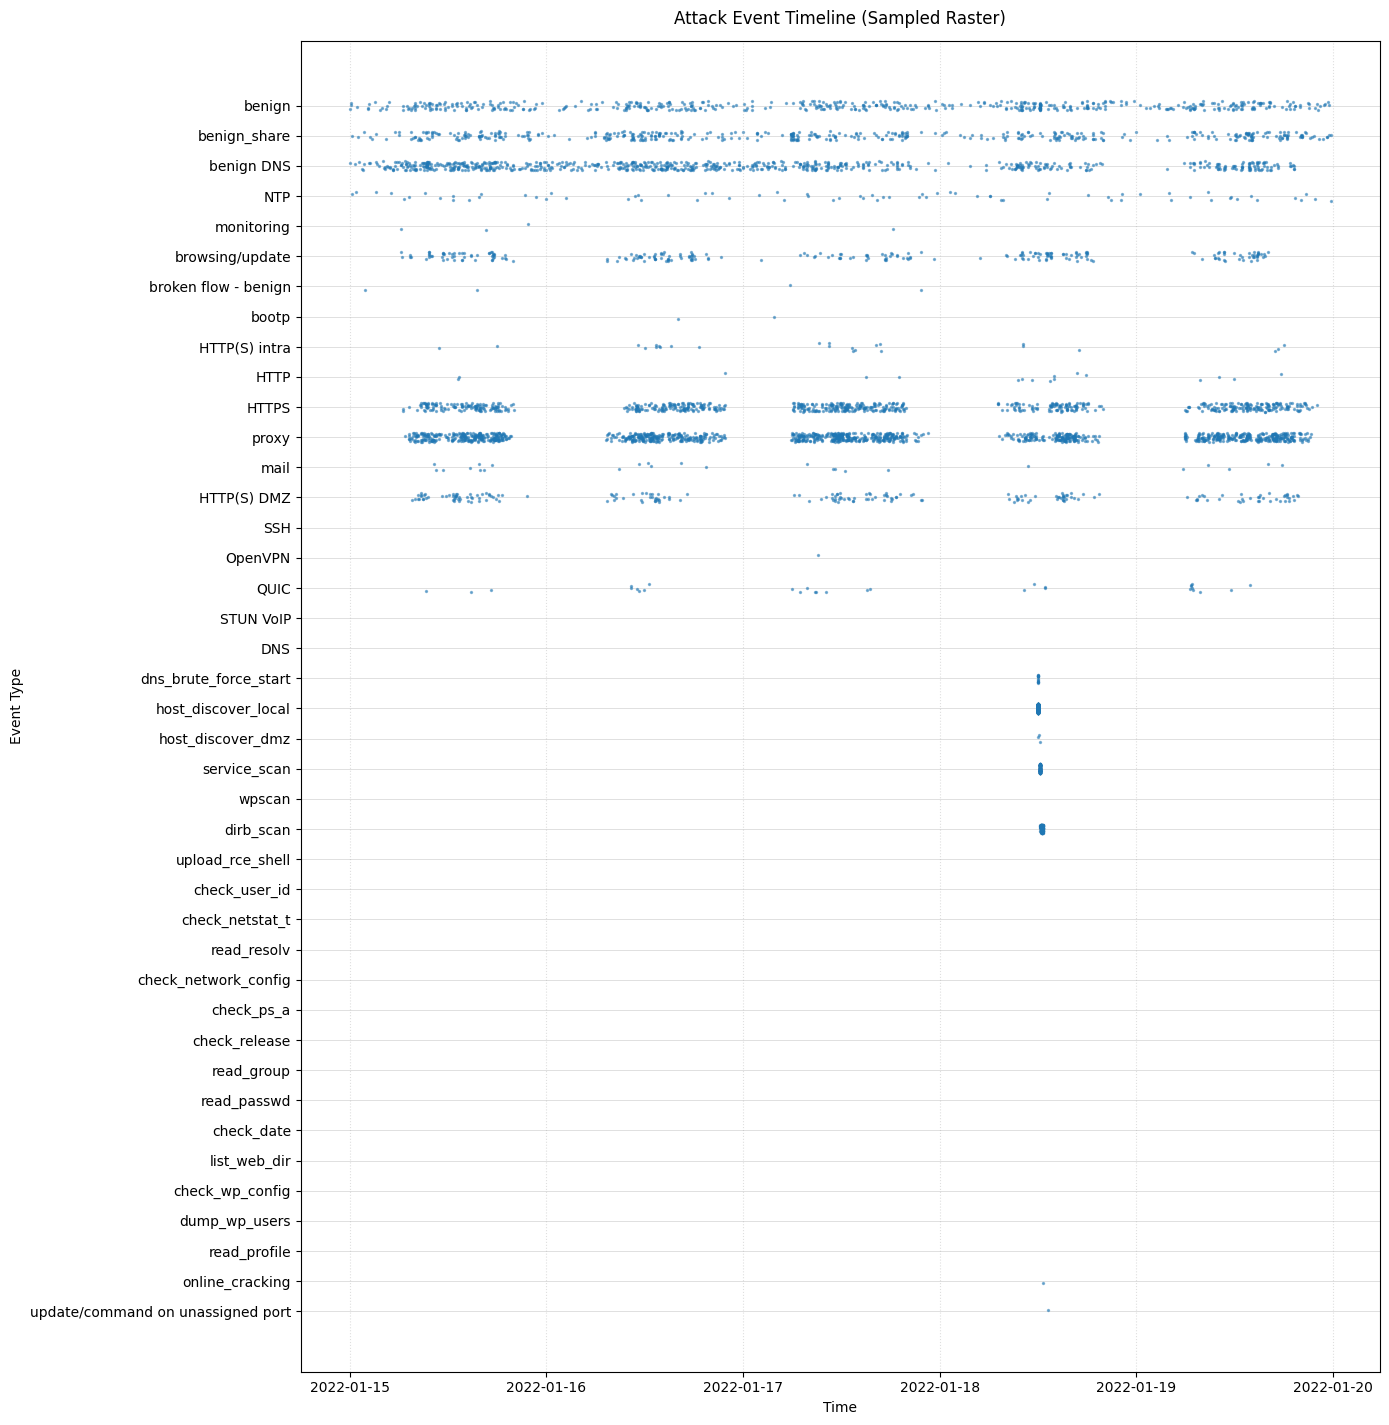

In [314]:
order_sim = phase_bounds_sim.index.tolist()
plot_event_raster(df_sim, order_sim)

### Only Attacks

In [315]:
benign_labels = ["DNS", "SSH", "HTTP(S) DMZ", "mail", "proxy", "HTTPS", "HTTP", "HTTP(S) intra", "browsing/update", "monitoring", "benign_share", "benign", "benign DNS", "NTP", "broken flow - benign", "bootp", "OpenVPN", "QUIC", "STUN VoIP"]
attack_labels = [lbl for lbl in all_labels if lbl not in benign_labels]
print("Benign labels:", benign_labels)
print("Attack labels:", attack_labels)

Benign labels: ['DNS', 'SSH', 'HTTP(S) DMZ', 'mail', 'proxy', 'HTTPS', 'HTTP', 'HTTP(S) intra', 'browsing/update', 'monitoring', 'benign_share', 'benign', 'benign DNS', 'NTP', 'broken flow - benign', 'bootp', 'OpenVPN', 'QUIC', 'STUN VoIP']
Attack labels: ['service_scan', 'online_cracking', 'host_discover_dmz', 'update/command on unassigned port', 'host_discover_local', 'wpscan', 'dirb_scan', 'upload_rce_shell', 'check_user_id', 'check_netstat_t', 'read_resolv', 'check_network_config', 'check_ps_a', 'check_release', 'read_group', 'read_passwd', 'check_date', 'list_web_dir', 'check_wp_config', 'dump_wp_users', 'read_profile', 'dns_brute_force_start', 'data exfiltration', 'mDNSv6', 'mDNS', 'systemd-resolver (local)', 'benign DNS - attacker requesting updates', 'NetBIOS']


In [316]:
attack_start_true = pd.Timestamp("2022-01-18 11:59")
attack_end_true   = pd.Timestamp("2022-01-18 13:15")

print(f"True attack period:")
print(f"{attack_start_true} to {attack_end_true}")
print()

df_attack = df[df["label"].isin(attack_labels)]
attack_start = df_attack["start_time_dt"].min()
attack_end = df_attack["end_time_dt"].max()

print(f"Attack period based on attack labels:")
print(f"{attack_start} to {attack_end}")
print()

print(f"Total attack flows in attack period: {len(df_attack)}")

True attack period:
2022-01-18 11:59:00 to 2022-01-18 13:15:00

Attack period based on attack labels:
2022-01-18 11:59:14.508178949 to 2022-01-18 13:14:51.076342106

Total attack flows in attack period: 53634


In [317]:
phase_bounds_attack = (
    df_attack[df_attack['label'].isin(attack_labels)]
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_attack

,min,max
label,,
dns_brute_force_start,2022-01-18 11:59:14.508178949,2022-01-18 11:59:14.608710051
host_discover_local,2022-01-18 11:59:24.763206005,2022-01-18 12:02:40.928086042
host_discover_dmz,2022-01-18 12:02:52.446352005,2022-01-18 12:14:50.528302908
service_scan,2022-01-18 12:17:14.234992027,2022-01-18 12:17:43.861294031
wpscan,2022-01-18 12:17:50.429045916,2022-01-18 12:18:13.388248920
dirb_scan,2022-01-18 12:18:30.335740089,2022-01-18 12:37:48.927057981
upload_rce_shell,2022-01-18 12:38:00.677339077,2022-01-18 12:38:00.677897930
check_user_id,2022-01-18 12:38:04.704194069,2022-01-18 12:38:04.704286098
check_netstat_t,2022-01-18 12:38:06.522208929,2022-01-18 12:38:06.522558928


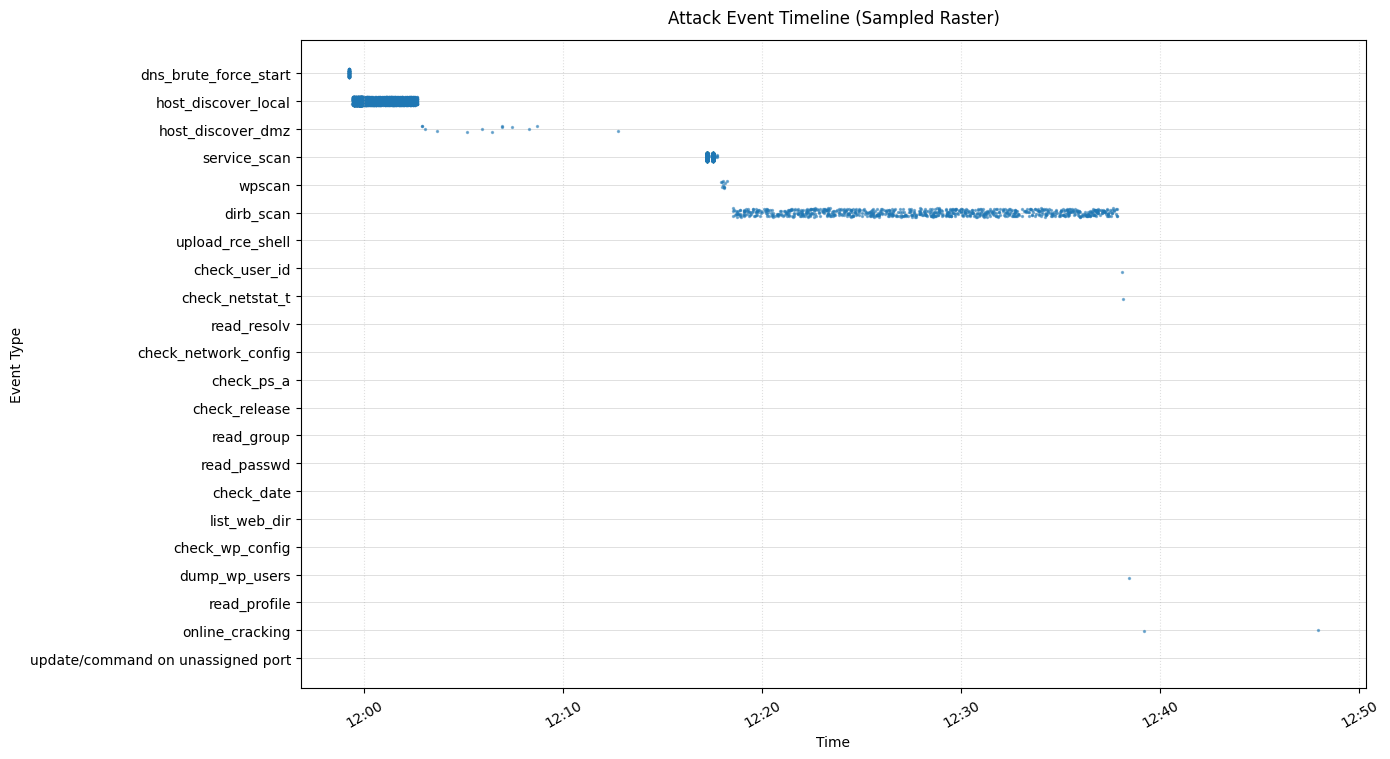

In [318]:
order_attack = phase_bounds_attack.index.tolist()
plot_event_raster(df_attack=df_attack, order=order_attack, attack=True)

## Dataset Statistics

In [319]:
def label_stats(df, sensor_host, plot_bar=True):
    label_counts = df["label"].value_counts()
    print("Label Distribution for {}:".format(sensor_host))
    print(label_counts)

    if plot_bar:
        bar = label_counts.plot(kind="bar")
        bar.set_title("Label Distribution - {}".format(sensor_host))
        bar.set_yscale("log")
    print()

In [320]:
def dataset_stats(df, print_details=True):
    total_flows = len(df)
    unique_src_ips = df["src_ip"].nunique()
    unique_dst_ips = df["dst_ip"].nunique()
    unique_src_ports = df["sport"].nunique()
    unique_dst_ports = df["dport"].nunique()

    if print_details:
        print(f"Total Flows: {total_flows}")
        print(f"Unique Source IPs: {unique_src_ips}")
        print(f"Unique Destination IPs: {unique_dst_ips}")
        print(f"Unique Source Ports: {unique_src_ports}")
        print(f"Unique Destination Ports: {unique_dst_ports}")

    return {
        "total_flows": total_flows,
        "unique_src_ips": unique_src_ips,
        "unique_dst_ips": unique_dst_ips,
        "unique_src_ports": unique_src_ports,
        "unique_dst_ports": unique_dst_ports,
    }

In [321]:
def dataset_stats_detailed(df, print_details=True):
    src_ips = df["src_ip"].value_counts()
    dst_ips = df["dst_ip"].value_counts()
    src_ports = df["sport"].value_counts()
    dst_ports = df["dport"].value_counts()

    if print_details:
        print("Total Flows:", len(df))

        print("\n --- IP distribution ---")
        print(f"\nSource IPs ({len(src_ips)}):")
        print(src_ips)
        print(f"\nDestination IPs ({len(dst_ips)}):")
        print(dst_ips)

        print("\n --- Port distribution ---")
        print(f"Source Ports ({len(src_ports)}):")
        print(src_ports)
        print(f"\nDestination Ports ({len(dst_ports)}):")
        print(dst_ports)

    return src_ips, dst_ips, src_ports, dst_ports

Label Distribution for webserver:
label
host_discover_local                  32788
service_scan                         11039
dirb_scan                             8254
dns_brute_force_start                 1192
host_discover_dmz                      143
wpscan                                 128
online_cracking                         60
upload_rce_shell                         2
check_netstat_t                          2
check_user_id                            2
check_network_config                     2
check_ps_a                               2
check_release                            2
read_resolv                              2
read_group                               2
read_passwd                              2
list_web_dir                             2
check_date                               2
check_wp_config                          2
dump_wp_users                            2
read_profile                             2
update/command on unassigned port        2
Name: count, d

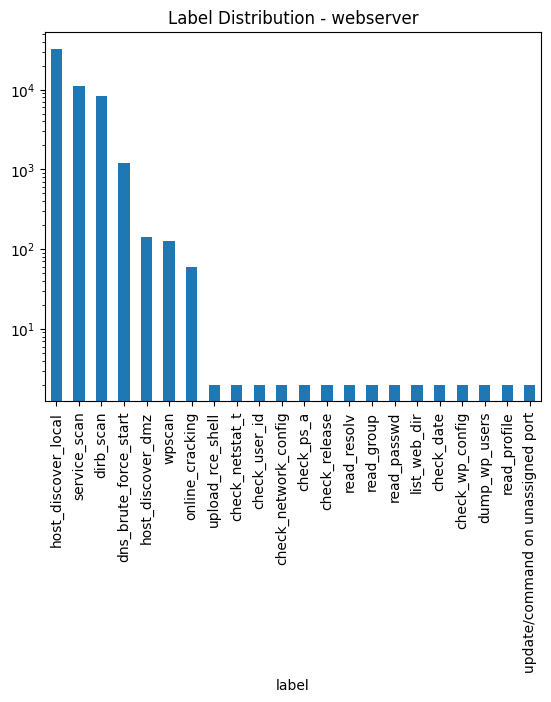

In [322]:
label_stats(df_attack, sensor_host)

In [323]:
# Sim dataset stats
dataset_stats(df)

Total Flows: 358477
Unique Source IPs: 115
Unique Destination IPs: 11336
Unique Source Ports: 43976
Unique Destination Ports: 2410


{'total_flows': 358477,
 'unique_src_ips': 115,
 'unique_dst_ips': 11336,
 'unique_src_ports': 43976,
 'unique_dst_ports': 2410}

In [324]:
# Attack flows stats
dataset_stats(df_attack)

Total Flows: 53634
Unique Source IPs: 4
Unique Destination IPs: 8203
Unique Source Ports: 13571
Unique Destination Ports: 1414


{'total_flows': 53634,
 'unique_src_ips': 4,
 'unique_dst_ips': 8203,
 'unique_src_ports': 13571,
 'unique_dst_ports': 1414}

In [325]:
dataset_stats_detailed(df_attack)

Total Flows: 53634

 --- IP distribution ---

Source IPs (4):
src_ip
172.17.130.196    52384
192.168.130.77     1243
192.168.128.4         5
10.35.35.206          2
Name: count, dtype: int64

Destination IPs (8203):
dst_ip
10.35.35.206       10716
172.17.130.37       2844
10.35.33.111        2488
172.17.129.140      2393
192.168.128.4       1208
                   ...  
10.35.32.1             1
172.17.128.63          1
34.243.160.129         1
151.101.14.109         1
192.168.255.254        1
Name: count, Length: 8203, dtype: int64

 --- Port distribution ---
Source Ports (13571):
sport
59174    17
59944    15
57950    15
59510    14
52666    14
         ..
41266     1
45346     1
47140     1
45082     1
47564     1
Name: count, Length: 13571, dtype: int64

Destination Ports (1414):
dport
443      25022
80       16526
587         27
993         15
139         14
         ...  
33554        5
823          4
1212         4
60123        4
51898        2
Name: count, Length: 1414, dtype: i

(src_ip
 172.17.130.196    52384
 192.168.130.77     1243
 192.168.128.4         5
 10.35.35.206          2
 Name: count, dtype: int64,
 dst_ip
 10.35.35.206       10716
 172.17.130.37       2844
 10.35.33.111        2488
 172.17.129.140      2393
 192.168.128.4       1208
                    ...  
 10.35.32.1             1
 172.17.128.63          1
 34.243.160.129         1
 151.101.14.109         1
 192.168.255.254        1
 Name: count, Length: 8203, dtype: int64,
 sport
 59174    17
 59944    15
 57950    15
 59510    14
 52666    14
          ..
 41266     1
 45346     1
 47140     1
 45082     1
 47564     1
 Name: count, Length: 13571, dtype: int64,
 dport
 443      25022
 80       16526
 587         27
 993         15
 139         14
          ...  
 33554        5
 823          4
 1212         4
 60123        4
 51898        2
 Name: count, Length: 1414, dtype: int64)

## Multi-Step Attack Labels

In [326]:
recon = ['dns_brute_force_start', 'host_discover_local', 'host_discover_dmz', 'service_scan', 'wpscan', 'dirb_scan']
exploit = ['upload_rce_shell', 'check_user_id', 'check_netstat_t', 'read_resolv', 'check_network_config', 'check_ps_a', 'check_release', 'read_group', 'read_passwd', 'check_date', 'list_web_dir', 'check_wp_config', 'dump_wp_users', 'read_profile']
cracking = ['online_cracking']
escalation = ['update/command on unassigned port']

In [327]:
df_sim = pd.read_csv(f"{data_dir}/all_labeled_sim.csv")

In [328]:
def label_phase(label):
    if label in recon:
        return 1
    elif label in exploit:
        return 2
    elif label in cracking:
        return 3
    elif label in escalation:
        return 4
    else:
        return 0

df_sim["phase"] = df_sim["label"].apply(label_phase)
label_counts = df_sim["phase"].value_counts()
print("Phase distribution:")
print(label_counts)

Phase distribution:
phase
0    304843
1     53544
3        60
2        28
4         2
Name: count, dtype: int64


In [329]:
df_sim.to_csv(f"{data_dir}/all_flows_labeled.csv", index=False)